<a href="https://colab.research.google.com/github/aswinss949/ICT-BATCH-9/blob/main/Case_study_on_Supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn import tree

from sklearn.metrics import confusion_matrix, precision_score, recall_score,f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

#load data sets

In [ ]:
train_df = pd.read_csv ('/content/drive/MyDrive/DSA session/Training_data (1).csv')
test_df = pd.read_csv ('/content/drive/MyDrive/DSA session/Testing_data (1).csv')

print("Training Data Head:")
display(train_df.head())

print("\nTesting Data Head:")
display(test_df.head())

Training Data Head:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No



Testing Data Head:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Training Data Info:")
train_df.info()

print("\nTesting Data Info:")
test_df.info()

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634

In [ ]:
print("Training Data Description:")
train_df.describe()

print("\nTesting Data Description:")
test_df.describe()

Training Data Description:

Testing Data Description:


,SeniorCitizen,tenure,MonthlyCharges
count,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013
std,0.377300,24.322161,30.282693
min,0.000000,0.000000,18.700000
25%,0.000000,8.000000,30.100000
50%,0.000000,27.000000,69.900000
75%,0.000000,54.000000,89.500000
max,1.000000,72.000000,118.600000


### Missing Values Analysis

In [ ]:
print("Missing values in Training Data:")
display(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nMissing values in Testing Data:")
display(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Missing values in Training Data:


,0
gender,169
OnlineSecurity,169
MonthlyCharges,394
TotalCharges,281



Missing values in Testing Data:


,0


In [ ]:
# Convert TotalCharges to numeric
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')


train_df['gender'] = train_df['gender'].fillna(train_df['gender'].mode()[0])
train_df['OnlineSecurity'] = train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0])
train_df['MonthlyCharges'] = train_df['MonthlyCharges'].fillna(train_df['MonthlyCharges'].median())
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(train_df['TotalCharges'].median())

In [ ]:
train_df.isnull().sum()
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


scaling training data

In [ ]:
min_max_scaler = MinMaxScaler() # using min- max scaler because the distribution is skewed

# Ensure 'TotalCharges' in train_df is numeric before scaling
train_df['TotalCharges'] = train_df['TotalCharges'].astype(str).str.strip()
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(train_df['TotalCharges'].median())

train_df[['tenure','MonthlyCharges','TotalCharges']] = min_max_scaler.fit_transform(train_df[['tenure','MonthlyCharges','TotalCharges']])

# Ensure 'TotalCharges' in test_df is numeric before scaling
test_df['TotalCharges'] = test_df['TotalCharges'].astype(str).str.strip()
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(test_df['TotalCharges'].median())

test_df[['tenure','MonthlyCharges','TotalCharges']] = min_max_scaler.fit_transform(test_df[['tenure','MonthlyCharges','TotalCharges']])

# Variable Distribution

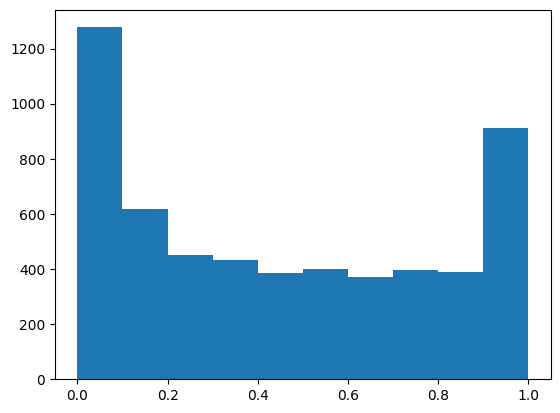

In [ ]:
plt.hist(train_df['tenure'])
plt.show()

# Numerical Feature Distributions


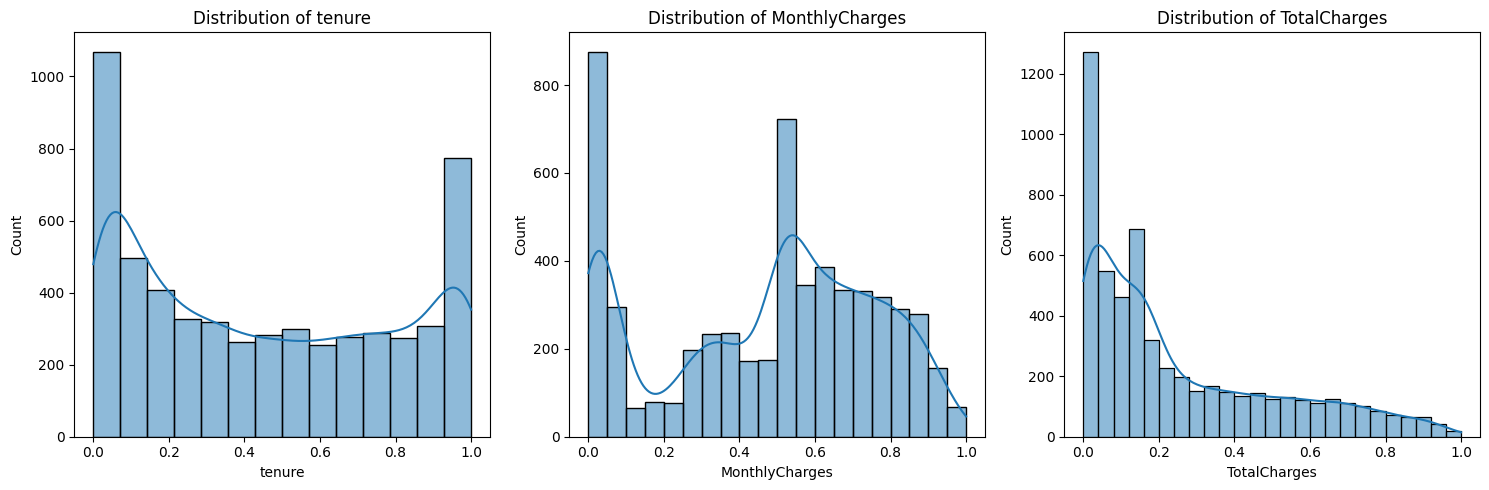

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3,i +1)
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Correlation Matrix


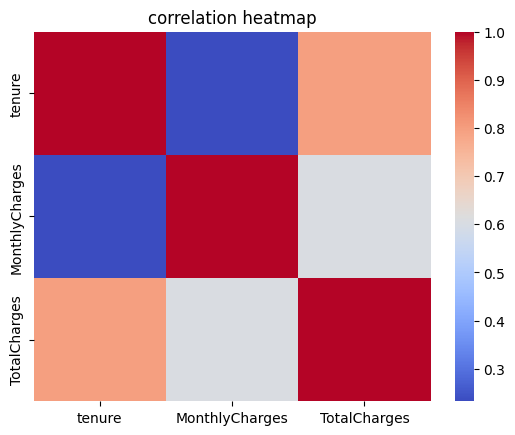

In [ ]:
corr_matrix = train_df[numerical_cols].corr(method='pearson')
corr_matrix


sns.heatmap(corr_matrix,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

Encoding

In [ ]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,0.486111,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0.024876,0.078653,No
1,7746-AWNQW,Female,0,No,No,0.388889,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,0.174129,0.108765,No
2,2208-UGTGR,Male,0,No,No,0.777778,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,0.799502,0.641845,No
3,4884-LEVMQ,Male,0,Yes,No,0.541667,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),0.021891,0.088986,No
4,6682-VCIXC,Female,0,Yes,Yes,0.597222,No,No phone service,DSL,No,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),0.328358,0.246107,No


In [ ]:
label_encoder = LabelEncoder()

train_df['Churn'] = label_encoder.fit_transform(train_df['Churn'])
train_df['PaperlessBilling'] = label_encoder.fit_transform(train_df['PaperlessBilling'])
train_df['Partner'] = label_encoder.fit_transform(train_df['Partner'])
train_df['gender'] = label_encoder.fit_transform(train_df['gender'])
train_df['Dependents'] = label_encoder.fit_transform(train_df['Dependents'])
train_df['PhoneService'] = label_encoder.fit_transform(train_df['PhoneService'])

In [ ]:
# applying one hot encoding in above mentioned columns in training data

train_df = pd.get_dummies(train_df, columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'], dtype=int)

In [ ]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,0.555556,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,0.625626,0.383837,No
1,7285-KLOTR,Female,0,Yes,No,0.166667,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,0.602102,0.100600,No
2,7486-KSRVI,Male,0,No,No,0.597222,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,0.813814,0.491625,Yes
3,9924-JPRMC,Male,0,No,No,1.000000,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,0.995996,1.000000,No
4,4439-YRNVD,Female,0,No,No,0.138889,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,0.175676,0.041649,No


In [ ]:
label_encoder = LabelEncoder()

test_df['Churn'] = label_encoder.fit_transform(test_df['Churn'])
test_df['PaperlessBilling'] = label_encoder.fit_transform(test_df['PaperlessBilling'])
test_df['Partner'] = label_encoder.fit_transform(test_df['Partner'])
test_df['gender'] = label_encoder.fit_transform(test_df['gender'])
test_df['Dependents'] = label_encoder.fit_transform(test_df['Dependents'])
test_df['PhoneService'] = label_encoder.fit_transform(test_df['PhoneService'])

In [ ]:
test_df = pd.get_dummies(test_df, columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'], dtype=int)

In [ ]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,6080-TCMYC,1,0,1,1,0.555556,1,1,0.625626,0.383837,...,1,0,0,1,0,0,0,0,1,0
1,7285-KLOTR,0,0,1,0,0.166667,1,0,0.602102,0.100600,...,0,0,1,0,1,0,0,0,1,0
2,7486-KSRVI,1,0,0,0,0.597222,1,1,0.813814,0.491625,...,0,0,1,0,1,0,0,0,1,0
3,9924-JPRMC,1,0,0,0,1.000000,1,1,0.995996,1.000000,...,0,0,1,0,0,1,0,0,1,0
4,4439-YRNVD,0,0,0,0,0.138889,0,0,0.175676,0.041649,...,1,0,0,1,0,0,0,0,1,0


### Outlier Detection


In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = train_df[(train_df[col] < lower_limit) | (train_df[col] > upper_limit)]
    print(f"Column: {col}")
    print(f"  Lower limit: {lower_limit:.2f}, Upper Bound: {upper_limit:.2f}")
    print(f"  Number of outliers: {len(outliers)}\n")

Column: tenure
  Lower limit: -0.85, Upper Bound: 1.76
  Number of outliers: 0

Column: MonthlyCharges
  Lower limit: -0.42, Upper Bound: 1.38
  Number of outliers: 0

Column: TotalCharges
  Lower limit: -0.49, Upper Bound: 0.96
  Number of outliers: 24



In [ ]:
outliers

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
93,0906-QVPMS,1,0,1,0,1.000000,1,0,0.964179,0.961303,...,0,0,1,0,0,1,1,0,0,0
111,0164-APGRB,0,0,0,0,1.000000,1,1,0.961692,0.978294,...,0,0,1,0,0,1,0,0,1,0
269,6007-TCTST,0,0,1,1,1.000000,1,1,0.970647,0.975963,...,0,0,1,0,0,1,1,0,0,0
665,0186-CAERR,1,0,0,0,0.986111,1,1,0.975622,0.956698,...,0,0,1,0,1,0,1,0,0,0
724,2388-LAESQ,0,1,1,0,1.000000,1,1,0.961194,0.957668,...,0,0,1,0,0,1,1,0,0,0
901,8513-OLYGY,1,0,1,0,1.000000,1,0,0.970647,0.959306,...,0,0,1,0,0,1,0,1,0,0
1666,1480-BKXGA,1,1,1,0,1.000000,1,1,0.973134,0.967701,...,0,0,1,0,0,1,1,0,0,0
1865,8015-IHCGW,0,0,1,1,1.000000,1,1,0.967662,0.970038,...,0,0,1,0,0,1,0,0,1,0
1959,9739-JLPQJ,0,0,1,1,1.000000,1,0,0.987562,0.998304,...,0,0,1,0,0,1,0,1,0,0
2085,2889-FPWRM,1,0,1,0,1.000000,1,1,0.990547,1.000000,...,0,0,1,0,1,0,1,0,0,0


### Visualizing Outliers with Boxplots

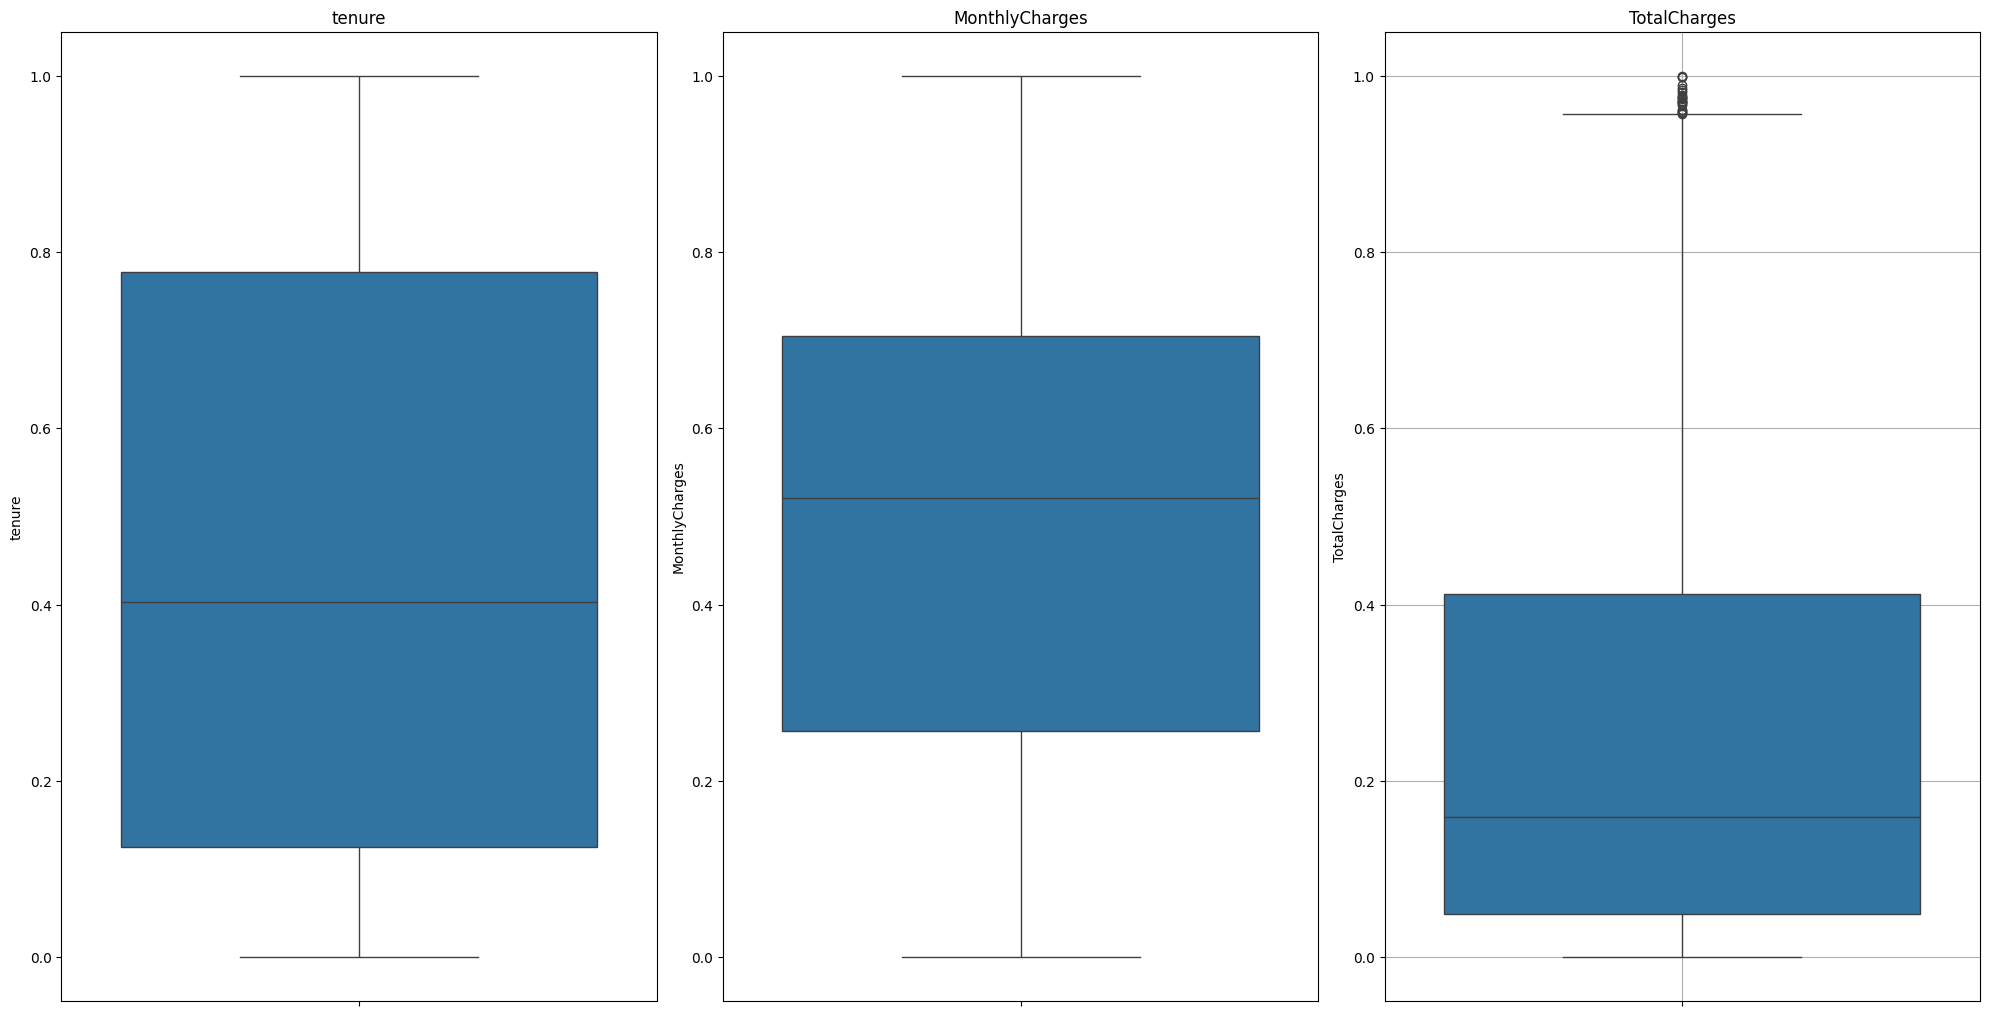

In [ ]:
plt.figure(figsize=(20, 30))
for i, col in enumerate(numerical_cols,1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=train_df[col] )
    plt.title (col)
plt.tight_layout()
plt.grid()

# Feature Engineering

In [ ]:

train_df['CustomerLifetimeValue'] = (

    train_df['tenure'] *
    train_df['MonthlyCharges']
)

test_df['CustomerLifetimeValue'] = (
    test_df['tenure'] *
    test_df['MonthlyCharges']
)

In [ ]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue
0,9509-MPYOD,0,0,0,0,0.486111,1,0,0.024876,0.078653,...,1,0,0,1,0,0,0,0,1,0.012092
1,7746-AWNQW,0,0,0,0,0.388889,0,1,0.174129,0.108765,...,0,0,1,0,0,0,0,0,1,0.067717
2,2208-UGTGR,1,0,0,0,0.777778,1,0,0.799502,0.641845,...,0,1,1,0,0,0,0,1,0,0.621835
3,4884-LEVMQ,1,0,1,0,0.541667,1,1,0.021891,0.088986,...,1,0,0,0,1,1,0,0,0,0.011857
4,6682-VCIXC,0,0,1,1,0.597222,0,1,0.328358,0.246107,...,0,0,0,1,0,1,0,0,0,0.196103


In [ ]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue
0,6080-TCMYC,1,0,1,1,0.555556,1,1,0.625626,0.383837,...,0,0,1,0,0,0,0,1,0,0.347570
1,7285-KLOTR,0,0,1,0,0.166667,1,0,0.602102,0.100600,...,0,1,0,1,0,0,0,1,0,0.100350
2,7486-KSRVI,1,0,0,0,0.597222,1,1,0.813814,0.491625,...,0,1,0,1,0,0,0,1,0,0.486028
3,9924-JPRMC,1,0,0,0,1.000000,1,1,0.995996,1.000000,...,0,1,0,0,1,0,0,1,0,0.995996
4,4439-YRNVD,0,0,0,0,0.138889,0,0,0.175676,0.041649,...,0,0,1,0,0,0,0,1,0,0.024399


###libraries


In [ ]:
import numpy as np
import pandas as pd
#evalution matrics
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score
#dataset
from sklearn.datasets import load_breast_cancer
#ml models
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn.neighbors import KNeighborsClassifier #k-nn
from sklearn.naive_bayes import GaussianNB   #naive bayes
from sklearn.svm import SVC  #svm
from sklearn.tree import DecisionTreeClassifier #decision tree
#spliting test_ train
from sklearn.model_selection import train_test_split

###spliting data

test train split

In [ ]:
# Define features X and target y
X_train= train_df.drop(['Churn', 'customerID'], axis=1)
y_train= train_df['Churn']
X_test = test_df.drop(['Churn', 'customerID'], axis=1)
y_test= test_df['Churn']

ml model building

In [ ]:
model_columns = X_train.columns

X_test = X_test.reindex(columns=model_columns, fill_value=0)

logreg_model= LogisticRegression()

logreg_model.fit(X_train,y_train)

y_pred_logistic_reg= logreg_model.predict(X_test)

In [ ]:

logreg_accuracy = accuracy_score(y_test, y_pred_logistic_reg)
logreg_conf_matrix = confusion_matrix(y_test, y_pred_logistic_reg)
log_reg_precision = precision_score(y_test, y_pred_logistic_reg)
log_reg_recall = recall_score(y_test, y_pred_logistic_reg)
log_reg_f1score = f1_score(y_test, y_pred_logistic_reg)


print(f"Accuracy is: {logreg_accuracy}")
print(f"confusion matrix is :{logreg_conf_matrix}")
print(f" Precision score is:{log_reg_precision}")
print(f" Recall score is:{log_reg_recall}")
print(f" f1 score is:{log_reg_f1score}")

Accuracy is: 0.8197303051809794
confusion matrix is :[[949  95]
 [159 206]]
 Precision score is:0.6843853820598007
 Recall score is:0.5643835616438356
 f1 score is:0.6186186186186187


knn

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train,y_train)
y_pred_knn = knn_model.predict(X_test)

In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_conf_matrix = confusion_matrix(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1score = f1_score(y_test, y_pred_knn)


print(f"Accuracy of knn is: {knn_accuracy}")
print(f"confusion matrix is :{knn_conf_matrix}")
print(f" Precision score is:{knn_precision}")
print(f" Recall score is:{knn_recall}")
print(f" f1 score is:{knn_f1score}")

Accuracy of knn is: 0.7473385379701917
confusion matrix is :[[867 177]
 [179 186]]
 Precision score is:0.512396694214876
 Recall score is:0.5095890410958904
 f1 score is:0.510989010989011


Naive bayes model

In [ ]:
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train,y_train)
y_pred_naivebs = naive_bayes_model.predict(X_test)

In [ ]:
nb_accuracy = accuracy_score(y_test, y_pred_naivebs)
nb_conf_matrix = confusion_matrix(y_test, y_pred_naivebs)
nb_precision = precision_score(y_test, y_pred_naivebs)
nb_recall = recall_score(y_test, y_pred_naivebs)
nb_f1score = f1_score(y_test, y_pred_naivebs)


print(f"Accuracy of naive bayes is: {nb_accuracy}")
print(f"confusion matrix is :{nb_conf_matrix}")
print(f" Precision score is:{nb_precision}")
print(f" Recall score is:{nb_recall}")
print(f" f1 score is:{nb_f1score}")

Accuracy of naive bayes is: 0.6792051100070973
confusion matrix is :[[662 382]
 [ 70 295]]
 Precision score is:0.4357459379615953
 Recall score is:0.8082191780821918
 f1 score is:0.5662188099808061


SVM Model

In [ ]:
svm_model = svm.SVC()
svm_model.fit(X_train,y_train)
y_pred_svm = svm_model.predict(X_test)

In [ ]:
svm_accuracy = accuracy_score(y_test,y_pred_svm )
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1score = f1_score(y_test, y_pred_svm)


print(f"Accuracy of SVM is: {svm_accuracy}")
print(f"confusion matrix is :{svm_conf_matrix}")
print(f" Precision score is:{svm_precision}")
print(f" Recall score is:{svm_recall}")
print(f" f1 score is:{svm_f1score}")


Accuracy of SVM is: 0.8069552874378992
confusion matrix is :[[952  92]
 [180 185]]
 Precision score is:0.6678700361010831
 Recall score is:0.5068493150684932
 f1 score is:0.5763239875389408



Decision Tree

In [ ]:
desicion_tree_model = tree.DecisionTreeClassifier()
desicion_tree_model.fit(X_train,y_train)
y_pred_dtree = desicion_tree_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test,y_pred_dtree )
dt_conf_matrix = confusion_matrix(y_test, y_pred_dtree)
dt_precision = precision_score(y_test, y_pred_dtree)
dt_recall = recall_score(y_test, y_pred_dtree)
dt_f1score = f1_score(y_test, y_pred_dtree)


print(f"Accuracy of Decision Tree is: {dt_accuracy}")
print(f"confusion matrix is :{dt_conf_matrix}")
print(f" Precision score is:{dt_precision}")
print(f" Recall score is:{dt_recall}")
print(f" F1 score is:{dt_f1score}")

Accuracy of Decision Tree is: 0.730305180979418
confusion matrix is :[[850 194]
 [186 179]]
 Precision score is:0.47989276139410186
 Recall score is:0.4904109589041096
 F1 score is:0.48509485094850946


# Random forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test,y_pred_rf )
rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1score = f1_score(y_test, y_pred_rf)

print(f"Accuracy of Random Forest is: {rf_accuracy}")
print(f"confusion matrix is :{rf_conf_matrix}")
print(f" Precision score is:{rf_precision}")
print(f" Recall score is:{rf_recall}")
print(f" f1 score is:{rf_f1score}")

Accuracy of Random Forest is: 0.7856635911994322
confusion matrix is :[[930 114]
 [188 177]]
 Precision score is:0.6082474226804123
 Recall score is:0.4849315068493151
 f1 score is:0.5396341463414634


In [ ]:
result_df = pd.DataFrame()
result_df['Model'] = ['Logistic Regression','KNN','Naive bayes','SVM','Decision Tree','Random Forest']
result_df['Accuracy'] = [logreg_accuracy,knn_accuracy,nb_accuracy,svm_accuracy,dt_accuracy,rf_accuracy]
result_df['Precision'] = [log_reg_precision,knn_precision,nb_precision,svm_precision,dt_precision,rf_precision]
result_df['Recall'] = [log_reg_recall,knn_recall,nb_recall,svm_recall,dt_recall,rf_recall]
result_df['f1 sccore'] = [log_reg_f1score,knn_f1score,nb_f1score,svm_f1score,dt_recall,rf_f1score]


In [ ]:

result_df

,Model,Accuracy,Precision,Recall,f1 sccore
0,Logistic Regression,0.819730,0.684385,0.564384,0.618619
1,KNN,0.747339,0.512397,0.509589,0.510989
2,Naive bayes,0.679205,0.435746,0.808219,0.566219
3,SVM,0.806955,0.667870,0.506849,0.576324
4,Decision Tree,0.730305,0.479893,0.490411,0.490411
5,Random Forest,0.785664,0.608247,0.484932,0.539634


Fine Tuning

In [ ]:
# Using GridSearchCV to fine tune the model
log_params = {
    'C': [0.01, 0.1, 1, 0.5],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

log_grid = GridSearchCV(
    LogisticRegression(),
    param_grid=log_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print("Best Parameters:", log_grid.best_params_)
print("Best F1 Score:", log_grid.best_score_)

tuned_log_model = log_grid.best_estimator_

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score: 0.6333618515101139


In [ ]:
y_pred_log_tuned = tuned_log_model.predict(X_test)
logreg_accuracy_tuned = accuracy_score(y_test, y_pred_log_tuned)
logreg_conf_matrix_tuned = confusion_matrix(y_test, y_pred_log_tuned)
log_reg_precision_tuned = precision_score(y_test, y_pred_log_tuned)
log_reg_recall_tuned = recall_score(y_test, y_pred_log_tuned)
log_reg_f1score_tuned = f1_score(y_test, y_pred_log_tuned)

print(f"Accuracy is: {logreg_accuracy_tuned}")
print(f"confusion matrix is :{logreg_conf_matrix_tuned}")
print(f" Precision score is:{log_reg_precision_tuned}")
print(f" Recall score is:{log_reg_recall_tuned}")
print(f" f1 score is:{log_reg_f1score_tuned}")

Accuracy is: 0.7331440738112136
confusion matrix is :[[749 295]
 [ 81 284]]
 Precision score is:0.4905008635578584
 Recall score is:0.7780821917808219
 f1 score is:0.6016949152542372


In [ ]:
# Using GridSearchCV to fine tune the model
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best F1 Score:", knn_grid.best_score_)

fine_tuned_knn_model = knn_grid.best_estimator_

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best F1 Score: 0.5737365953965935


In [ ]:
y_pred_knn_fine_tuned = fine_tuned_knn_model.predict(X_test)
knn_accuracy_tuned = accuracy_score(y_test, y_pred_knn_fine_tuned)
knn_conf_matrix_tuned = confusion_matrix(y_test, y_pred_knn_fine_tuned)
knn_precision_tuned = precision_score(y_test, y_pred_knn_fine_tuned)
knn_recall_tuned = recall_score(y_test, y_pred_knn_fine_tuned)
knn_f1score_tuned = f1_score(y_test, y_pred_knn_fine_tuned)

print(f"Accuracy of knn is: {knn_accuracy_tuned}")
print(f"confusion matrix is :{knn_conf_matrix_tuned}")
print(f" Precision score is:{knn_precision_tuned}")
print(f" Recall score is:{knn_recall_tuned}")
print(f" f1 score is:{knn_f1score_tuned}")

Accuracy of knn is: 0.7856635911994322
confusion matrix is :[[902 142]
 [160 205]]
 Precision score is:0.590778097982709
 Recall score is:0.5616438356164384
 f1 score is:0.5758426966292135


In [ ]:
# Using GridSearchCV to fine tune the model

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

svm_grid = GridSearchCV(
    svm.SVC(),
    param_grid=svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best F1 Score:", svm_grid.best_score_)

fine_tuned_svm_model = svm_grid.best_estimator_

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best F1 Score: 0.6278300495649489


In [ ]:
y_pred_svm_fine_tuned = fine_tuned_svm_model.predict(X_test)
svm_accuracy_tuned = accuracy_score(y_test,y_pred_svm_fine_tuned )
svm_conf_matrix_tuned = confusion_matrix(y_test, y_pred_svm_fine_tuned)
svm_precision_tuned = precision_score(y_test, y_pred_svm_fine_tuned)
svm_recall_tuned = recall_score(y_test, y_pred_svm_fine_tuned)
svm_f1score_tuned = f1_score(y_test, y_pred_svm_fine_tuned)

print(f"Accuracy of SVM is: {svm_accuracy_tuned}")
print(f"confusion matrix is :{svm_conf_matrix_tuned}")
print(f" Precision score is:{svm_precision_tuned}")
print(f" Recall score is:{svm_recall_tuned}")
print(f" f1 score is:{svm_f1score_tuned}")

Accuracy of SVM is: 0.7203690560681334
confusion matrix is :[[744 300]
 [ 94 271]]
 Precision score is:0.4746059544658494
 Recall score is:0.7424657534246575
 f1 score is:0.5790598290598291


In [ ]:
# Using GridSearchCV to fine tune the model
dt_params = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    tree.DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best F1 Score:", dt_grid.best_score_)

fine_tuned_dt_model = dt_grid.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best F1 Score: 0.5820902022628268


In [ ]:
y_pred_dt_fine_tuned = fine_tuned_dt_model.predict(X_test)

In [ ]:
dt_accuracy_tuned = accuracy_score(y_test,y_pred_dt_fine_tuned )
dt_conf_matrix_tuned = confusion_matrix(y_test, y_pred_dt_fine_tuned)
dt_precision_tuned = precision_score(y_test, y_pred_dt_fine_tuned)
dt_recall_tuned = recall_score(y_test, y_pred_dt_fine_tuned)
dt_f1score_tuned = f1_score(y_test, y_pred_dt_fine_tuned)

print(f"Accuracy of Decision Tree is: {dt_accuracy_tuned}")
print(f"confusion matrix is :{dt_conf_matrix_tuned}")
print(f" Precision score is:{dt_precision_tuned}")
print(f" Recall score is:{dt_recall_tuned}")
print(f" r1 score is:{dt_f1score_tuned}")

Accuracy of Decision Tree is: 0.7892122072391767
confusion matrix is :[[890 154]
 [143 222]]
 Precision score is:0.5904255319148937
 Recall score is:0.6082191780821918
 r1 score is:0.5991902834008097


In [ ]:
# Using RandomizedSearchCV because Random Forest has many combinations.

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)
print("Best F1 Score:", rf_random.best_score_)

fine_tuned_rf_model = rf_random.best_estimator_

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}
Best F1 Score: 0.6435446199610358


In [ ]:
y_pred_rf_fine_tuned = fine_tuned_rf_model.predict(X_test)
rf_accuracy_tuned = accuracy_score(y_test,y_pred_rf_fine_tuned )
rf_conf_matrix_tuned = confusion_matrix(y_test, y_pred_rf_fine_tuned)
rf_precision_tuned = precision_score(y_test, y_pred_rf_fine_tuned)
rf_recall_tuned = recall_score(y_test, y_pred_rf_fine_tuned)
rf_f1score_tuned = f1_score(y_test, y_pred_rf_fine_tuned)

print(f"Accuracy of Random Forest is: {rf_accuracy_tuned}")
print(f"confusion matrix is :{rf_conf_matrix_tuned}")
print(f" Precision score is:{rf_precision_tuned}")
print(f" Recall score is:{rf_recall_tuned}")
print(f" F1 score is:{rf_f1score_tuned}")

Accuracy of Random Forest is: 0.7572746628814763
confusion matrix is :[[805 239]
 [103 262]]
 Precision score is:0.5229540918163673
 Recall score is:0.7178082191780822
 F1 score is:0.605080831408776


In [ ]:
# Evaluvation comparison after hyperparameter tuning

result_df = pd.DataFrame()
result_df['Model'] = ['Logistic Regression','KNN','Naive bayes','SVM','Decision Tree','Random Forest',
                      'Logistic Regression Hypertuned','KNN Hypertuned','SVM Hypertuned','Decision Tree Hypertuned','Random Forest hypertuned']
result_df['Accuracy'] = [logreg_accuracy,knn_accuracy,nb_accuracy,svm_accuracy,dt_accuracy,rf_accuracy,
                         logreg_accuracy_tuned,knn_accuracy_tuned,svm_accuracy_tuned,dt_accuracy_tuned,rf_accuracy_tuned]
result_df['Precision'] = [log_reg_precision,knn_precision,nb_precision,svm_precision,dt_precision,rf_precision,
                          log_reg_precision_tuned,knn_precision_tuned,svm_precision_tuned,dt_precision_tuned,rf_precision_tuned]
result_df['Recall'] = [log_reg_recall,knn_recall,nb_recall,svm_recall,dt_recall,rf_recall,
                       log_reg_recall_tuned,knn_recall_tuned,svm_recall_tuned,dt_recall_tuned,rf_recall_tuned]
result_df['f1 Score'] = [log_reg_f1score,knn_f1score,nb_f1score,svm_f1score,dt_f1score,rf_f1score,
                       log_reg_f1score_tuned,knn_f1score_tuned,svm_f1score_tuned,dt_f1score_tuned,rf_f1score_tuned]



result_df

,Model,Accuracy,Precision,Recall,f1 Score
0,Logistic Regression,0.819730,0.684385,0.564384,0.618619
1,KNN,0.747339,0.512397,0.509589,0.510989
2,Naive bayes,0.679205,0.435746,0.808219,0.566219
3,SVM,0.806955,0.667870,0.506849,0.576324
4,Decision Tree,0.730305,0.479893,0.490411,0.485095
5,Random Forest,0.785664,0.608247,0.484932,0.539634
6,Logistic Regression Hypertuned,0.733144,0.490501,0.778082,0.601695
7,KNN Hypertuned,0.785664,0.590778,0.561644,0.575843
8,SVM Hypertuned,0.720369,0.474606,0.742466,0.579060
9,Decision Tree Hypertuned,0.789212,0.590426,0.608219,0.599190
